In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import sklearn as sk





[Data Source](https://omniweb.gsfc.nasa.gov/ftpbrowser/soho_ephin_flux_hr.html)

In [30]:
proton_flux_df = pd.read_csv('data/enviromental/proton_flux_1995Dec-2002Jan_EPHINSOHO.lst', header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+") 

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Lewis\AppData\Local\Temp\ipykernel_26920\2333429118.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  proton_flux_df = pd.read_csv('data/enviromental/proton_flux_1995Dec-2002Jan_EPHINSOHO.lst', header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+")


# Power Law Spectrum
**[Torres 2025](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024SW003921)**: The 
10 MeV proton intensity is calculated from the differential fluxes in four energy (P4, P8, P25, and P41) channels through an integration over the energy. The P8 proton channel covers an energy range of 7.8–25 MeV, P25 covers 25–40.9 MeV, P41 covers 40.9–53 MeV, while the P4 channel covers 4.3–7.8 MeV. We assume that particles above the P41 channel coverage make little contribution to the integral flux of MeV protons. The integral flux is calculated by summing energy-integrated fluxes in the last three (P8, P25, and P41) channels minus the amount between 7.8 and 10 MeV, which is determined by the integration of a power-law spectrum interpolated using the differential fluxes in the first two channels (P4 and P8) and their mean energies. We use the first two channels to do the interpolation because their fluxes have relatively low error bars due to high count rates in low-energy channels.

Too find channel between 7.8- 10 MeV we fall the Power Law Scale and make use of its invariance:

$\Phi_n = \alpha \nu_n^\beta$ (1)

Using the channels P4 and P8:

$\Phi_4 = \alpha \nu_4^\beta$ (2) 

$\Phi_8 = \alpha \nu_8^\beta$ (3)

Converting frequency to energy: $\nu_n = \frac{\bar{E}_n}{h}$ (4), $h = 4.136 \times 10^{-21} \text{Mev/s}$

Rewriting (2): $\alpha = \frac{\Phi_4}{\nu_4^\beta}$

And then plugging into (3): $\Phi_8 = \Phi_4 \left(\frac{\nu_8}{\nu_4} \right)^\beta$ (5)

Solving for $\beta$: $\beta = \frac{\log [\Phi_8 / \Phi_4]}{\log [\nu_8 / \nu_4]}$

Solving for $\alpha$: $\alpha = \frac{\Phi_4}{\nu_4^\beta}$ With newly discovered $\beta$

Now we can solve the flux over any range we want using our new parameters $\alpha, \beta$: $\Phi_x = \alpha \nu_x^\beta$




In [31]:
def Power_Law_Spectrum_Flux(a_lower_bound_energy, a_upper_bound_energy, a_p4_flux, a_p4_avg_E,  a_p8_flux, a_p8_avg_E):
    h = 4.136e-21 # MeV / s
    a_p4_freq = a_p4_avg_E / h
    a_p8_freq = a_p8_avg_E / h
    new_freq  = (a_lower_bound_energy + a_upper_bound_energy)/(2*h)
    beta_denom = np.log(a_p8_freq / a_p4_freq) 



    beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
    alpha = a_p4_flux / a_p4_freq**beta
    new_flux = alpha * new_freq ** beta

    return new_flux

In [32]:
def Integrating_Flux(a_df):
    new_channel_lower_bound = 7.8
    new_channel_upper_bound = 10
    p4_avg_energy = (4.3+7.8)/2 # MeV
    p8_avg_energy = (25+7.8) / 2 # MeV

    a_df["Px"] = a_df.apply(
        lambda row: Power_Law_Spectrum_Flux(
            new_channel_lower_bound, 
            new_channel_upper_bound, 
            row["P4"], 
            p4_avg_energy, 
            row["P8"], 
            p8_avg_energy
        ), 
        axis=1
    )
    a_df["P_tot"] = a_df["P4"] + a_df["P25"] + a_df["P41"] - a_df["Px"]
    a_df["Timestamp"] = pd.to_datetime(a_df["Year"], format="%Y") + pd.to_timedelta(a_df["DOY"] - 1, unit = "D") + pd.to_timedelta(a_df["Hour"], unit = "h")
    a_df = a_df[a_df["P_tot"] != 1.999980e+06] # Cleaned from error numbers?
    return a_df
proton_flux_df = Integrating_Flux(proton_flux_df)

C:\Users\Lewis\AppData\Local\Temp\ipykernel_26920\1720685650.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
C:\Users\Lewis\AppData\Local\Temp\ipykernel_26920\1720685650.py:12: RuntimeWarning: invalid value encountered in scalar multiply
  new_flux = alpha * new_freq ** beta
C:\Users\Lewis\AppData\Local\Temp\ipykernel_26920\1720685650.py:10: RuntimeWarning: invalid value encountered in scalar divide
  beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
C:\Users\Lewis\AppData\Local\Temp\ipykernel_26920\1720685650.py:10: RuntimeWarning: divide by zero encountered in log
  beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
C:\Users\Lewis\AppData\Local\Temp\ipykernel_26920\1720685650.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = a_p4_flux / a_p4_freq**beta


# Finding Onset, Peaks, and Ends
No specific technique was explained rather the "program" will sort it. heres my attempt and i will compare with theirs


1 .1235232
2 .6567657
3 .87614567
4 .67986
5 .23548278345
6 .234587589345




In [33]:
def Timestamp_Proton_Flux(a_indices, a_df):
    proton_fluxes = a_df["P_tot"]
    years         = a_df["Year"]
    DOYs          = a_df["DOY"]
    hours         = a_df["Hour"]

    fluxes = proton_fluxes.loc[a_indices]
    years  = years.loc[a_indices]
    DOY    = DOYs.loc[a_indices]
    hours  = hours.loc[a_indices]
    timestamp = pd.to_datetime(years, format="%Y") + pd.to_timedelta(DOY - 1, unit="D") + pd.to_timedelta(hours, unit="h")

    return fluxes, timestamp

def Find_Proton_Flux_Phases(a_df, a_range, a_file_name):
    proton_fluxes = a_df["P_tot"]
    years         = a_df["Year"]
    DOYs          = a_df["DOY"]
    hours         = a_df["Hour"]


    peak_indices, properties = find_peaks(proton_fluxes.to_list(), height = 10, distance = a_range )
    
    start_onset_indices = peak_indices - np.ones(len(peak_indices)) * a_range
    start_end_indices = peak_indices + np.ones(len(peak_indices)) * a_range

    peak_years = a_df["Year"].iloc[peak_indices]
    peak_DOYs  = a_df["DOY"].iloc[peak_indices]
    peak_hours = a_df["Hour"].iloc[peak_indices]
    peak_dates = pd.to_datetime(peak_years, format="%Y") + pd.to_timedelta(peak_DOYs - 1, unit="D")
    peak_timestamp = peak_dates + pd.to_timedelta(peak_hours, unit="h")
  

    onset_indices = []
    end_indices = []
    threshold_indices = []

    proton_fluxes = proton_fluxes.sort_index()

    for i in range(len(peak_indices)):
        onset_slice = proton_fluxes.iloc[int(start_onset_indices[i]): int(peak_indices[i])]
        onset_min_index = onset_slice.idxmin()
        onset_indices.append(onset_min_index)


        threshold_slice = proton_fluxes.iloc[int(start_onset_indices[i]): int(peak_indices[i])]

        #print(threshold_slice, proton_fluxes.iloc[int(peak_indices[i])], peak_indices[i])

        threshold_geq_10 = threshold_slice[threshold_slice > 10]
        
        if threshold_geq_10.empty:
            threshold_geq_10_index = onset_min_index
        else:

            threshold_geq_10_index = threshold_geq_10.index[0]
       # print(threshold_first_number_greater_than_10)
        threshold_indices.append(threshold_geq_10_index)


        end_slice = proton_fluxes.iloc[int(peak_indices[i]): int(start_end_indices[i])]
        end_min_index = end_slice.idxmin()
        end_indices.append(end_min_index)

    
    onset_fluxes, onset_timestamp = Timestamp_Proton_Flux(onset_indices, proton_flux_df)
    end_fluxes, end_timestamp     = Timestamp_Proton_Flux(end_indices, proton_flux_df)
    threshold_fluxes, threshold_timestamp = Timestamp_Proton_Flux(threshold_indices, proton_flux_df)
    peak_fluxes = pd.Series(properties['peak_heights'])



 ### ADD THRESHOLD ### > 10MeV



    phases_df = pd.DataFrame({'Onset Timestamp': onset_timestamp,
                            'Onset Flux': onset_fluxes,
                            'Threshold Timestamp': threshold_timestamp,
                            'Threshold Flux': threshold_fluxes,
                            'Peak Timestamp': peak_timestamp,
                            'Peak Flux': peak_fluxes,
                            'End Timestamp': end_timestamp,
                            'End Flux': end_fluxes})
    
    phase_df = phases_df.apply(lambda col : col.dropna().reset_index(drop = True))
    phase_df.to_csv("data/phases/" + a_file_name + "-"+str(a_range) + ".csv")
    storm_duration_in_days = phase_df["End Timestamp"] - phase_df["Onset Timestamp"]
    phase_df["Storm Duration"] = phase_df["End Timestamp"] - phase_df["Onset Timestamp"]
    return phase_df

Find_Proton_Flux_Phases(proton_flux_df, 200, "phases_11061997_11032002")



,Onset Timestamp,Onset Flux,Threshold Timestamp,Threshold Flux,Peak Timestamp,Peak Flux,End Timestamp,End Flux,Storm Duration
0,1997-10-30 05:00:00,0.000050,1997-11-06 22:00:00,13.861737,1997-11-07 06:00:00,48.236460,1997-11-13 21:00:00,0.015577,14 days 16:00:00
1,1998-04-19 23:00:00,0.000400,1998-04-21 00:00:00,11.187188,1998-04-21 10:00:00,31.837132,1998-04-28 11:00:00,0.044970,8 days 12:00:00
2,1998-05-02 14:00:00,0.027606,1998-05-02 14:00:00,0.027606,1998-05-06 10:00:00,17.482761,1998-05-14 10:00:00,0.007618,11 days 20:00:00
3,1998-11-04 13:00:00,0.000112,1998-11-06 09:00:00,10.984583,1998-11-06 15:00:00,17.353562,1998-11-13 07:00:00,0.000530,8 days 18:00:00
4,1999-04-22 21:00:00,0.000006,1999-04-22 21:00:00,0.000006,1999-04-25 01:00:00,11.289432,1999-05-03 00:00:00,0.000086,10 days 03:00:00
5,1999-05-03 00:00:00,0.000086,1999-05-03 00:00:00,0.000086,1999-05-06 01:00:00,12.007922,1999-05-13 23:00:00,0.002560,10 days 23:00:00
6,1999-05-27 08:00:00,0.000145,1999-06-02 06:00:00,10.309662,1999-06-04 14:00:00,27.388799,1999-06-12 19:00:00,0.018232,16 days 11:00:00
7,2000-04-04 06:00:00,0.000111,2000-04-05 01:00:00,11.364914,2000-04-05 19:00:00,51.056354,2000-04-13 18:00:00,0.000308,9 days 12:00:00
8,2000-06-02 16:00:00,0.000003,2000-06-07 15:00:00,11.314685,2000-06-08 11:00:00,133.659056,2000-06-15 17:00:00,0.009635,13 days 01:00:00
9,2000-07-07 16:00:00,0.000009,2000-07-14 13:00:00,18.966487,2000-07-15 15:00:00,423.557413,2000-07-23 19:00:00,0.136516,16 days 03:00:00


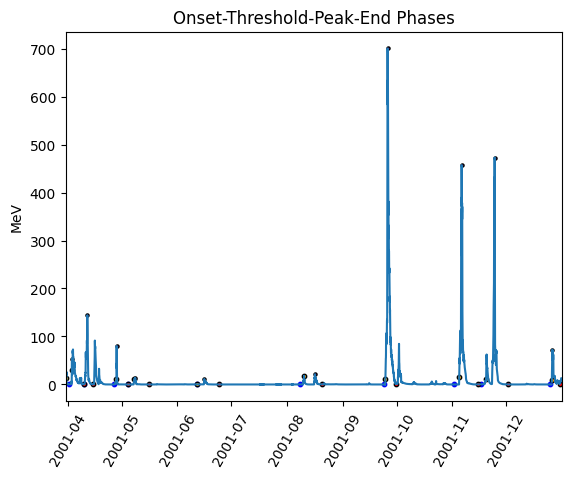

In [34]:
phase_data_df = Find_Proton_Flux_Phases(proton_flux_df, 200, "phases_11061997_11032002")

plt.title("Onset-Threshold-Peak-End Phases")
plt.ylabel("MeV")
plt.style.use("default")
plt.plot(proton_flux_df["Timestamp"], proton_flux_df["P_tot"])


plt.scatter(phase_data_df["Onset Timestamp"], phase_data_df["Onset Flux"], c = "blue", s = 10 )


plt.scatter(phase_data_df["Threshold Timestamp"], phase_data_df["Threshold Flux"], c ="orange", s = 10, edgecolors= "black" )

plt.scatter(phase_data_df["End Timestamp"], phase_data_df["End Flux"], c ="red", s = 10, edgecolors= "black" )

plt.scatter(phase_data_df["Peak Timestamp"], phase_data_df["Peak Flux"], c = "purple", s = 5, edgecolors= "black")

plt.xticks(rotation = 60)

plt.xlim(
    pd.Timestamp("2001-03-30 19:00:00"),
    pd.Timestamp("2001-12-31 19:00:00")
)
plt.show()

# Linear Regression of SEU instances and Proton fluxes

Testing with the GOES-16 SEU timestamped data

In [35]:
goes_16_seu_df = pd.read_excel("data/seu_timestamp/g16_g17_exs_spw.xlsx", sheet_name= "g16_exs_spw" )

goes_16_proton_flux = pd.read_csv("data/enviromental/proton_flux_2016Dec-2022Mar_EPHINSOHO.lst", header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+")
goes_16_proton_flux = Integrating_Flux(goes_16_proton_flux)

goes_16_proton_flux_phases = Find_Proton_Flux_Phases(goes_16_proton_flux, 200, "goes16_proton_flux_phases")

<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Lewis\AppData\Local\Temp\ipykernel_26920\2205999252.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  goes_16_proton_flux = pd.read_csv("data/enviromental/proton_flux_2016Dec-2022Mar_EPHINSOHO.lst", header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+")
C:\Users\Lewis\AppData\Local\Temp\ipykernel_26920\1720685650.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
C:\Users\Lewis\AppData\Local\Temp\ipykernel_26920\1720685650.py:12: RuntimeWarning: invalid value encountered in s

42242
1920


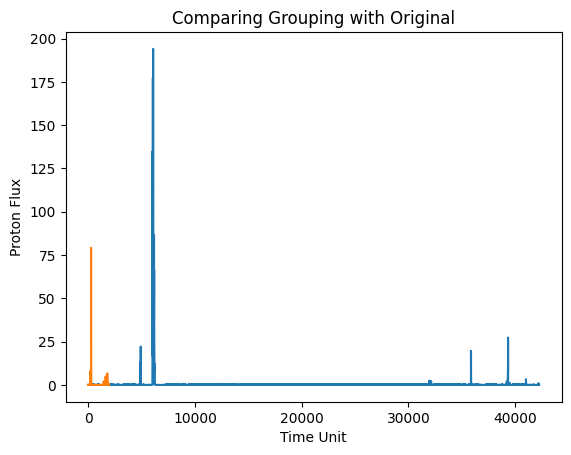

In [36]:

goes_16_seu_df["Count"] = np.ones(goes_16_seu_df.shape[0])


goes_16_seu_rate_df = goes_16_seu_df.groupby(pd.Grouper(key= "Datetime", freq = "D")).sum() 
goes_16_proton_flux_mean = goes_16_proton_flux.groupby(pd.Grouper(key = "Timestamp", freq = "D")).mean()
print(goes_16_proton_flux.shape[0])
print(goes_16_proton_flux_mean.shape[0])
plt.title("Comparing Grouping with Original")
plt.xlabel("Time Unit")
plt.ylabel("Proton Flux")
plt.plot(np.arange(0, len(goes_16_proton_flux["P_tot"].to_numpy()),1),goes_16_proton_flux["P_tot"].to_numpy())
plt.plot(np.arange(0, len(goes_16_proton_flux_mean["P_tot"].to_numpy()),1),goes_16_proton_flux_mean["P_tot"].to_numpy())
plt.show()

In [37]:
X = goes_16_proton_flux_mean["P_tot"].to_numpy()
X = np.where(np.isnan(X),0,X)
X = X.reshape(-1,1)



y = goes_16_seu_rate_df["Count"].to_numpy()
hour_diff = X.shape[0] - y.shape[0]
y = y[:hour_diff] # delete March 13 since proton flux didnt have it


X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X,y,test_size = .20)



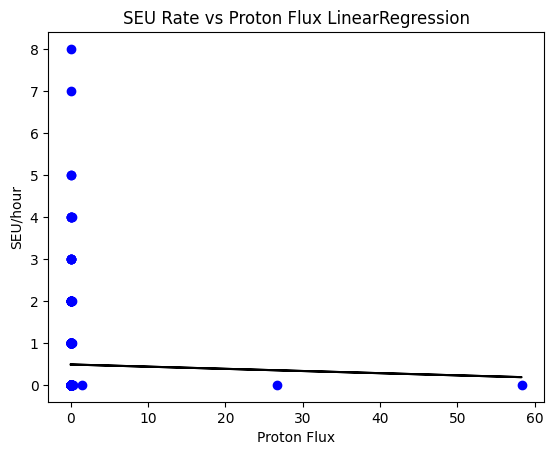

Mean Absolute Error: 0.6697083902037976
Mean Sqaure Error: 0.9562131937296731
Root Mean Square Error: 0.9778615411854957
Model Score: -0.0009112783653317802


In [38]:
def Lin_Fit_SEU_Rate_Proton_Flux(a_X_train, a_X_test, a_y_train, a_y_test, a_model):


    a_model.fit(a_X_train, a_y_train)
    y_pred = a_model.predict(a_X_test)
    plt.scatter(a_X_test, a_y_test, color = "b")
    plt.xlabel("Proton Flux")
    plt.title("SEU Rate vs Proton Flux " +type(a_model).__name__)
    plt.ylabel("SEU/hour")


    
    plt.plot(a_X_test, y_pred, color = 'k')
    plt.show()
    

    
    print("Mean Absolute Error:", sk.metrics.mean_absolute_error(y_true= y_test, y_pred = y_pred))
    print("Mean Sqaure Error:", sk.metrics.mean_squared_error(y_true = y_test, y_pred = y_pred))
    print("Root Mean Square Error:", np.sqrt(sk.metrics.mean_squared_error(y_true = y_test, y_pred = y_pred)))
    print("Model Score:", a_model.score(X_test,y_test))


# for name, class_ in sk.utils.all_estimators():

Lin_Fit_SEU_Rate_Proton_Flux(X_train, X_test, y_train, y_test, sk.linear_model.LinearRegression())

The average linear regression model score tends to 0 indicating a non linear relationship between SEU occurences and proton fluxes, not enough occurences of SEUs in dataset, too noisy?


I tried using the sklearn gaussian process regressor but this takes way to long with 45,000 data points for both proton flux and hourly seu. I have a 5070 on my desktop and im going to use it. here comes gpytorch: https://richardcsuwandi.medium.com/gaussian-process-regression-using-gpytorch-2c174286f9cc

In [39]:
# kernel = 1.0 * sk.gaussian_process.kernels.RBF(length_scale = 1.0)
# gp = sk.gaussian_process.GaussianProcessRegressor(kernel = kernel)
# def Gauss_Fit_SEU_Rate_Proton_Flux(a_X_train, a_X_test, a_y_train, a_y_test, a_model):

#     # Fit model
#     a_model.fit(a_X_train, a_y_train)
    
#     # Predict
#     y_pred = a_model.predict(a_X_test)

#     # Plot
#     plt.scatter(a_X_test, a_y_test, color="b")
#     plt.xlabel("Proton Flux")
#     plt.ylabel("SEU/hour")
#     plt.title("SEU Rate vs Proton Flux " + type(a_model).__name__)

#     # Sort for smooth curve
#     sorted_idx = np.argsort(a_X_test.flatten())
#     plt.plot(a_X_test.flatten()[sorted_idx], y_pred[sorted_idx], color='k')

#     plt.show()

#     # Metrics
#     print("Mean Absolute Error:", sk.metrics.mean_absolute_error(a_y_test, y_pred))
#     print("Mean Squared Error:", sk.metrics.mean_squared_error(a_y_test, y_pred))
#     print("Root Mean Square Error:", np.sqrt(sk.metrics.mean_squared_error(a_y_test, y_pred)))
#     print("Model Score:", a_model.score(a_X_test, a_y_test))

# Gauss_Fit_SEU_Rate_Proton_Flux(X_train,X_test,y_train,y_test, gp)

In [ ]:
import gpytorch as gp
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()

# -------------------------
# Define GP Model
# -------------------------
class SpectralMixtureGP(gp.models.ExactGP):
    def __init__(self, x_train, y_train, likelihood):
        super(SpectralMixtureGP, self).__init__(x_train, y_train, likelihood)
        self.mean = gp.means.ConstantMean() # Construct the mean function
        self.cov = gp.kernels.SpectralMixtureKernel(num_mixtures=4) # Construct the kernel function
        self.cov.initialize_from_data(x_train, y_train) # Initialize the hyperparameters from data
        
    def forward(self, x):
        # Evaluate the mean and kernel function at x
        mean_x = self.mean(x)
        cov_x = self.cov(x)
        # Return the multivariate normal distribution using the evaluated mean and kernel function
        return gp.distributions.MultivariateNormal(mean_x, cov_x) 
        
# Initialize the likelihood and model
likelihood = gp.likelihoods.GaussianLikelihood()
model = SpectralMixtureGP(X_train, y_train, likelihood)

# -------------------------
# Initialize likelihood + model ON GPU
# -------------------------
likelihood = gp.likelihoods.GaussianLikelihood()
model = SpectralMixtureGP(X_train, y_train, likelihood)

# -------------------------
# Training mode
# -------------------------
model.train()
likelihood.train()

# -------------------------
# Optimizer + Loss
# -------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gp.mlls.ExactMarginalLogLikelihood(likelihood, model)

# -------------------------
# Training loop
# -------------------------
n_iter = 50

for i in range(n_iter):
    optimizer.zero_grad()

    output = model(X_train)  # stays on GPU
    loss = -mll(output, y_train)

    loss.backward()

    print(f"Iter {i+1}/{n_iter} - Loss: {loss.item():.3f}")

    optimizer.step()

Using Device: cuda


c:\Users\Lewis\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\linear_operator\utils\linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 329.2755432128906 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


Iter 1/50 - Loss: -2.102


c:\Users\Lewis\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\linear_operator\utils\linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 955.8494262695312 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


Iter 2/50 - Loss: 37.409


...

Iter 20/50 - Loss: -0.638


c:\Users\Lewis\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\linear_operator\utils\linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 1169.3975830078125 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


Iter 21/50 - Loss: 1.146


c:\Users\Lewis\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\linear_operator\utils\linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 1358.28515625 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


Iter 22/50 - Loss: -0.124


In [ ]:
model.eval()
likelihood.eval()

X_test = torch.from_numpy(X_test)
y_test = torch.from_numpy(y_test)

with torch.no_grad(), gp.settings.fast_pred_var():
    # Obtain the predictive mean and covariance matrix
    f_preds = model(X_test)
    f_mean = f_preds.mean
    f_cov = f_preds.covariance_matrix
    
    # Make predictions by feeding model through likelihood
    observed_pred = likelihood(model(X_test))
    
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(8, 6))
    # Get upper and lower confidence bounds
    lower, upper = observed_pred.confidence_region()
    # Plot training data as black stars
    ax.plot(X_train.numpy(), y_train.numpy(), 'k*')
    # Plot predictive means as blue line
    ax.plot(X_test.numpy(), observed_pred.mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(X_test.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    ax.set_ylim([-3, 3])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])


TypeError: expected np.ndarray (got Tensor)